# Toxic Comment Classification with PyTorch and LSTM

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import re
import torch
import torch
import torch.nn as nn


from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [52]:

train_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv"

df = pd.read_csv(train_path)
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    Exploratory data analysis

</div>

In [53]:
df.shape ,df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


((159571, 8), None)

In [54]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [55]:
df["comment_text"].sample(5, random_state=42)

119105    Geez, are you forgetful!  We've already discus...
131631    Carioca RFA \n\nThanks for your support on my ...
125326    "\n\n Birthday \n\nNo worries, It's what I do ...
111256    Pseudoscience category? \n\nI'm assuming that ...
83590     (and if such phrase exists, it would be provid...
Name: comment_text, dtype: object

In [56]:
df.nunique()

id               159571
comment_text     159571
toxic                 2
severe_toxic          2
obscene               2
threat                2
insult                2
identity_hate         2
dtype: int64

In [57]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

for col in label_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


toxic:
toxic
0    144277
1     15294
Name: count, dtype: int64

severe_toxic:
severe_toxic
0    157976
1      1595
Name: count, dtype: int64

obscene:
obscene
0    151122
1      8449
Name: count, dtype: int64

threat:
threat
0    159093
1       478
Name: count, dtype: int64

insult:
insult
0    151694
1      7877
Name: count, dtype: int64

identity_hate:
identity_hate
0    158166
1      1405
Name: count, dtype: int64


In [58]:
df["comment_length"] = df["comment_text"].str.len()

df["comment_length"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64

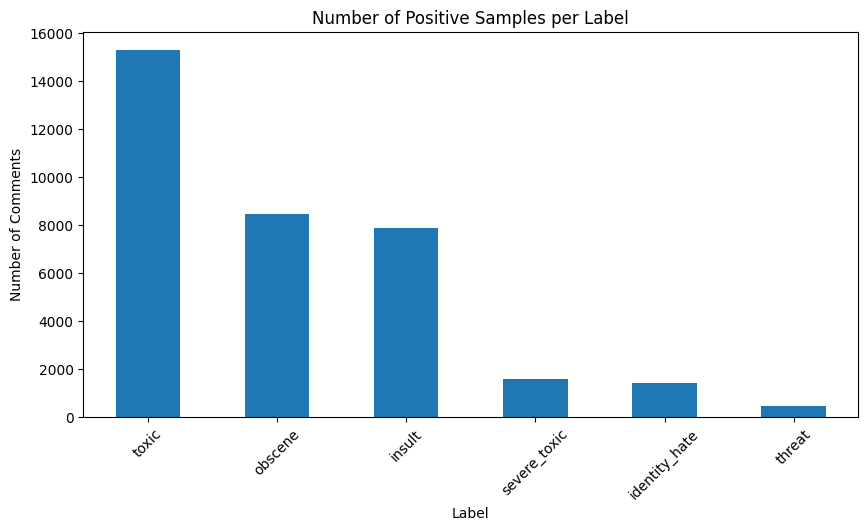

In [59]:

label_counts = df[label_columns].sum().sort_values(ascending=False)

label_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Positive Samples per Label")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

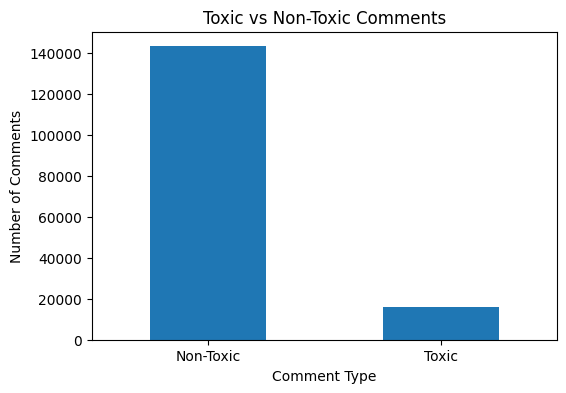

In [60]:

df["any_toxic"] = df[label_columns].sum(axis=1) > 0


df["any_toxic"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")

plt.xticks(
    [0, 1],
    ["Non-Toxic", "Toxic"],
    rotation=0
)

plt.show()

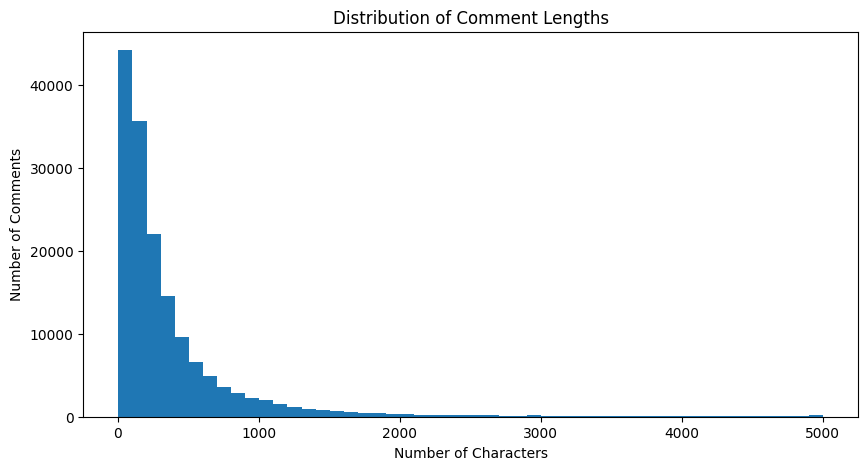

In [61]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

plt.show()

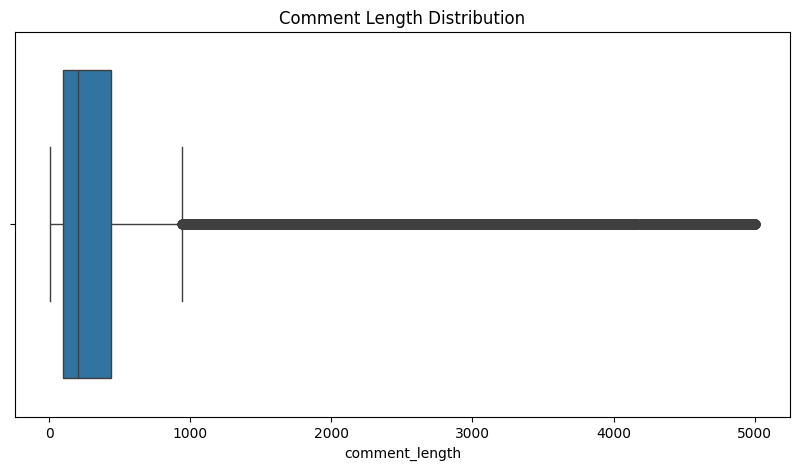

In [62]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["comment_length"]
)

plt.title("Comment Length Distribution")

plt.show()

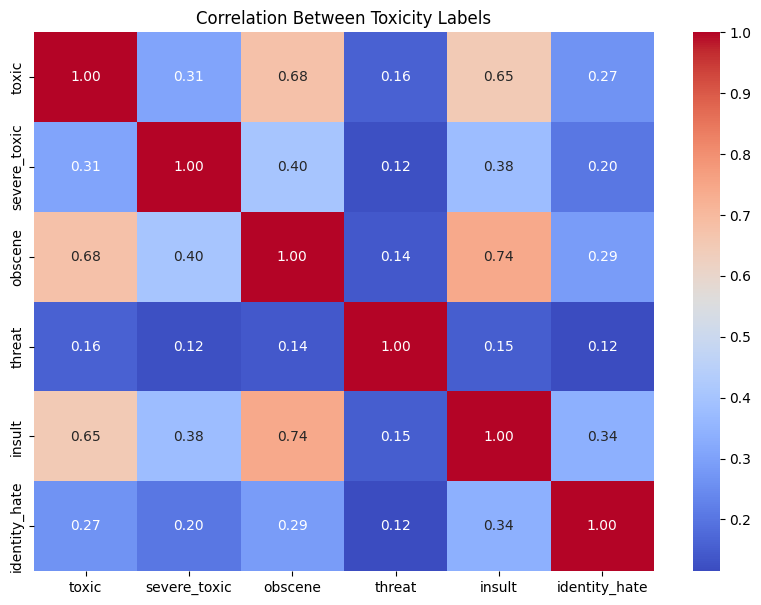

In [63]:
label_corr = df[label_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    label_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Toxicity Labels")

plt.show()

<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    Data Preprocessing
</div>

In [64]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

X = df["comment_text"].astype(str)
y = df[label_columns].values.astype(np.float32)

In [65]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["comment_text"].apply(clean_text)

In [66]:
print("Original:")
print(df["comment_text"].iloc[0])

print("\nCleaned:")
print(df["clean_text"].iloc[0])

Original:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Cleaned:
explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now


In [67]:
X_train, X_val, y_train, y_val = train_test_split(
    df["clean_text"],
    df[label_columns],
    test_size=0.2,
    random_state=42
)

In [68]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Training: (127656,)
Validation: (31915,)
y_train: (127656, 6)
y_val: (31915, 6)


In [69]:

def tokenize(text):
    return text.split()




counter = Counter()

for text in X_train:
    counter.update(tokenize(text))


counter.most_common(20)

[('the', 399080),
 ('to', 238867),
 ('i', 193251),
 ('and', 180193),
 ('of', 180106),
 ('you', 174586),
 ('a', 173716),
 ('is', 141374),
 ('that', 128794),
 ('it', 119154),
 ('in', 116924),
 ('for', 82444),
 ('this', 78391),
 ('not', 75181),
 ('on', 72267),
 ('be', 66739),
 ('as', 62226),
 ('s', 59500),
 ('have', 57916),
 ('are', 57656)]

In [70]:
MAX_VOCAB_SIZE = 50000

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, count in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 50000


In [71]:
def text_to_ids(text):
    tokens = tokenize(text)
    
    return [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

In [72]:
sample_text = X_train.iloc[0]

print("Text:")
print(sample_text)

print("\nIDs:")
print(text_to_ids(sample_text))

Text:
grandma terri should burn in trash grandma terri is trash i hate grandma terri f k her to hell

IDs:
[12053, 7654, 60, 3731, 12, 4116, 12053, 7654, 9, 4116, 4, 385, 12053, 7654, 468, 877, 185, 3, 816]


In [73]:
train_lengths = [
    len(text_to_ids(text))
    for text in X_train
]

In [74]:
print("Mean:", np.mean(train_lengths))
print("Median:", np.median(train_lengths))
print("95th percentile:", np.percentile(train_lengths, 95))
print("Maximum:", np.max(train_lengths))

Mean: 67.84266309456665
Median: 36.0
95th percentile: 232.0
Maximum: 1403


In [75]:
MAX_LEN = int(np.percentile(train_lengths, 95))

print("MAX_LEN:", MAX_LEN)

MAX_LEN: 232


In [76]:
class ToxicCommentDataset(Dataset):

    def __init__(self, texts, labels, vocab):
        self.texts = texts.tolist()
        self.labels = labels.values.astype(np.float32)
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]
        tokens = tokenize(text)

        token_ids = [
            self.vocab.get(token, self.vocab[UNK_TOKEN])
            for token in tokens
        ]

        x = torch.tensor(token_ids, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)

        return x, y

In [77]:
train_dataset = ToxicCommentDataset(
    X_train,
    y_train,
    vocab
)

val_dataset = ToxicCommentDataset(
    X_val,
    y_val,
    vocab
)

In [78]:
from torch.nn.utils.rnn import pad_sequence

In [79]:
def collate_fn(batch):

    sequences, labels = zip(*batch)

    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    labels = torch.stack(labels)

    return sequences, labels

In [80]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [81]:
x_batch, y_batch = next(iter(train_loader))

print("X shape:", x_batch.shape)
print("Y shape:", y_batch.shape)

X shape: torch.Size([64, 638])
Y shape: torch.Size([64, 6])


<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    The Model
</div>

In [82]:


class ToxicLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=2,
        num_classes=6,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output

In [83]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [84]:
model = ToxicLSTM(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=6,
    dropout=0.3
)

model = model.to(device)

print(model)

ToxicLSTM(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [85]:
pos_weight = []

for i, label in enumerate(label_columns):

    positive = y_train[label].sum()
    negative = len(y_train[label]) - positive

    weight = negative / positive

    pos_weight.append(weight)

    print(
        f"{label}: "
        f"Positive = {int(positive)}, "
        f"Negative = {int(negative)}, "
        f"pos_weight = {weight:.2f}"
    )

pos_weight = torch.tensor(
    pos_weight,
    dtype=torch.float32
).to(device)

toxic: Positive = 12238, Negative = 115418, pos_weight = 9.43
severe_toxic: Positive = 1274, Negative = 126382, pos_weight = 99.20
obscene: Positive = 6734, Negative = 120922, pos_weight = 17.96
threat: Positive = 404, Negative = 127252, pos_weight = 314.98
insult: Positive = 6263, Negative = 121393, pos_weight = 19.38
identity_hate: Positive = 1111, Negative = 126545, pos_weight = 113.90


In [86]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(criterion)
print(optimizer)

BCEWithLogitsLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [87]:
EPOCHS = 20

for epoch in range(EPOCHS):

    # Training
    model.train()

    total_train_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )


    # Validation
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_val_loss += loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )


    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/20] Train Loss: 1.3357 Val Loss: 1.3178
Epoch [2/20] Train Loss: 1.2789 Val Loss: 1.1544
Epoch [3/20] Train Loss: 1.1336 Val Loss: 1.1199
Epoch [4/20] Train Loss: 1.1204 Val Loss: 1.0235
Epoch [5/20] Train Loss: 1.0408 Val Loss: 1.0183
Epoch [6/20] Train Loss: 1.1763 Val Loss: 1.0412
Epoch [7/20] Train Loss: 0.9960 Val Loss: 1.0785
Epoch [8/20] Train Loss: 0.7426 Val Loss: 0.7364
Epoch [9/20] Train Loss: 0.8167 Val Loss: 0.9474
Epoch [10/20] Train Loss: 0.7785 Val Loss: 0.6997
Epoch [11/20] Train Loss: 0.6240 Val Loss: 0.5257
Epoch [12/20] Train Loss: 0.4602 Val Loss: 0.4423
Epoch [13/20] Train Loss: 0.3803 Val Loss: 0.3957
Epoch [14/20] Train Loss: 0.3295 Val Loss: 0.3776
Epoch [15/20] Train Loss: 0.2976 Val Loss: 0.3916
Epoch [16/20] Train Loss: 0.2681 Val Loss: 0.4153
Epoch [17/20] Train Loss: 0.2481 Val Loss: 0.4496
Epoch [18/20] Train Loss: 0.2321 Val Loss: 0.4871
Epoch [19/20] Train Loss: 0.2143 Val Loss: 0.5057
Epoch [20/20] Train Loss: 0.1995 Val Loss: 0.5043


In [88]:

test_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv"
test_labels_path = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv"

test_df = pd.read_csv(test_path)
test_labels_df = pd.read_csv(test_labels_path)

print("Test data shape:", test_df.shape)
print("Test labels shape:", test_labels_df.shape)

print("\nTest data:")
display(test_df.head())

print("\nTest labels:")
display(test_labels_df.head())

Test data shape: (153164, 2)
Test labels shape: (153164, 7)

Test data:


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.



Test labels:


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [89]:
test_df["clean_text"] = (
    test_df["comment_text"]
    .astype(str)
    .apply(clean_text)
)

print(test_df[["comment_text", "clean_text"]].head())

                                        comment_text  \
0  Yo bitch Ja Rule is more succesful then you'll...   
1  == From RfC == \n\n The title is fine as it is...   
2  " \n\n == Sources == \n\n * Zawe Ashton on Lap...   
3  :If you have a look back at the source, the in...   
4          I don't anonymously edit articles at all.   

                                          clean_text  
0  yo bitch ja rule is more succesful then you ll...  
1            from rfc the title is fine as it is imo  
2                     sources zawe ashton on lapland  
3  if you have a look back at the source the info...  
4           i don t anonymously edit articles at all  


In [90]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]



In [91]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


class TestToxicCommentDataset(Dataset):

    def __init__(self, texts, vocab):
        self.texts = texts.tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]

        tokens = tokenize(text)

        token_ids = [
            self.vocab.get(
                token,
                self.vocab[UNK_TOKEN]
            )
            for token in tokens
        ]

        if len(token_ids) == 0:
            token_ids = [self.vocab[UNK_TOKEN]]

        x = torch.tensor(
            token_ids,
            dtype=torch.long
        )

        return x

In [92]:
test_dataset = TestToxicCommentDataset(
    test_df["clean_text"],
    vocab
)


test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=lambda batch: pad_sequence(
        batch,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )
)

print("Number of test batches:", len(test_loader))

Number of test batches: 2394


In [93]:
model.eval()

test_predictions = []

with torch.no_grad():

    for x_batch in test_loader:

        x_batch = x_batch.to(device)

        outputs = model(x_batch)

        probabilities = torch.sigmoid(outputs)

        test_predictions.append(
            probabilities.cpu().numpy()
        )


test_predictions = np.vstack(test_predictions)

print("Test predictions shape:", test_predictions.shape)

Test predictions shape: (153164, 6)


In [94]:
test_true_labels = test_labels_df[label_columns].values

print("True labels shape:", test_true_labels.shape)

True labels shape: (153164, 6)


In [95]:
test_predictions_binary = (
    test_predictions >= 0.5
).astype(int)

print("Binary predictions shape:", test_predictions_binary.shape)

Binary predictions shape: (153164, 6)


In [96]:
from sklearn.metrics import classification_report

for i, label in enumerate(label_columns):

    mask = test_true_labels[:, i] != -1

    y_true = test_true_labels[mask, i]
    y_pred = test_predictions_binary[mask, i]

    print("\n" + "=" * 60)
    print(f"Classification Report - {label}")
    print("=" * 60)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Non-" + label,
                label
            ],
            zero_division=0
        )
    )


Classification Report - toxic
              precision    recall  f1-score   support

   Non-toxic       0.99      0.81      0.89     57888
       toxic       0.35      0.95      0.51      6090

    accuracy                           0.83     63978
   macro avg       0.67      0.88      0.70     63978
weighted avg       0.93      0.83      0.86     63978


Classification Report - severe_toxic
                  precision    recall  f1-score   support

Non-severe_toxic       1.00      0.94      0.97     63611
    severe_toxic       0.08      0.93      0.15       367

        accuracy                           0.94     63978
       macro avg       0.54      0.94      0.56     63978
    weighted avg       0.99      0.94      0.96     63978


Classification Report - obscene
              precision    recall  f1-score   support

 Non-obscene       1.00      0.85      0.92     60287
     obscene       0.28      0.96      0.43      3691

    accuracy                           0.85     63978
  

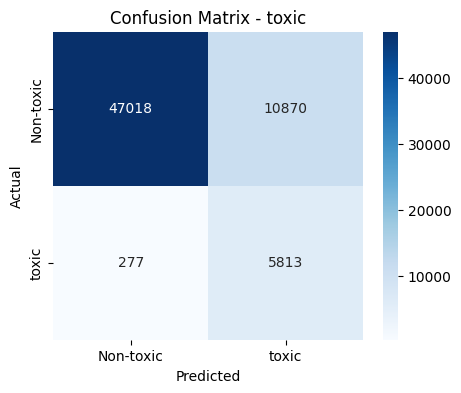

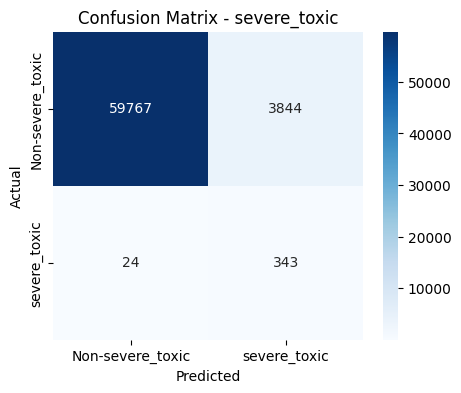

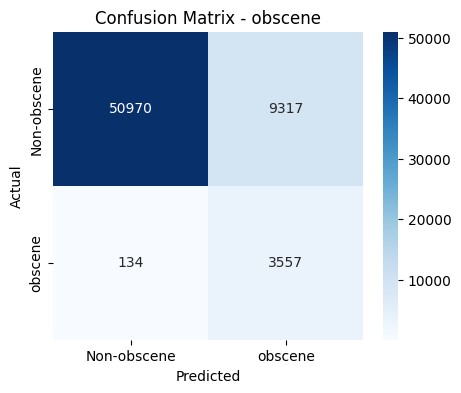

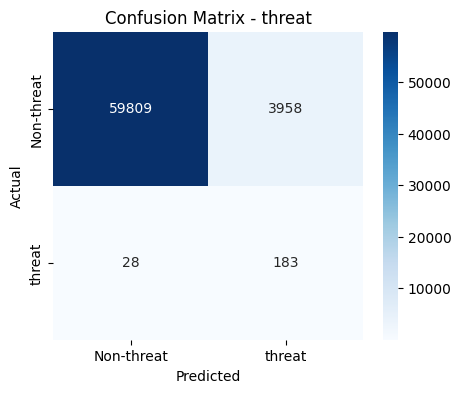

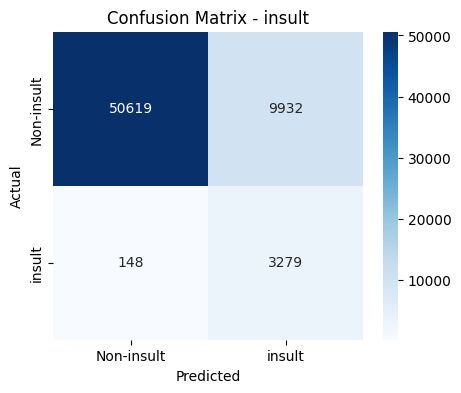

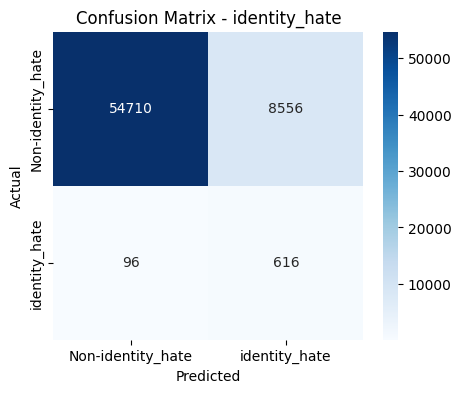

In [97]:


for i, label in enumerate(label_columns):

    mask = test_true_labels[:, i] != -1

    y_true = test_true_labels[mask, i]
    y_pred = test_predictions_binary[mask, i]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Non-" + label,
            label
        ],
        yticklabels=[
            "Non-" + label,
            label
        ]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {label}")

    plt.show()